# 🛡️ WomanGuard: Indeks Kerentanan Perempuan Berbasis Feminisasi Kemiskinan dan Pemberdayaan Ekonomi
## Pemetaan Prioritas Pembangunan Perempuan di Kota Surabaya

---

**WomanGuard** adalah sebuah sistem indeks komposit yang dirancang untuk mengukur dan memetakan tingkat kerentanan perempuan di setiap kecamatan di Kota Surabaya. Indeks ini dibangun berdasarkan dua dimensi utama:

1. **Feminisasi Kemiskinan** — mengukur sejauh mana perempuan lebih terdampak oleh kemiskinan dibandingkan laki-laki
2. **Pemberdayaan Ekonomi Perempuan** — mengukur akses dan partisipasi perempuan dalam aktivitas ekonomi dan pendidikan

### 📌 Variabel yang Digunakan

| Kode | Variabel | Dimensi |
|------|----------|---------|
| X1 | Persentase kepala keluarga berstatus cerai hidup per kecamatan | Feminisasi Kemiskinan |
| X2 | Persentase keluarga miskin | Feminisasi Kemiskinan |
| X3 | Persentase kepala keluarga perempuan | Feminisasi Kemiskinan |
| X4 | Persentase kepala keluarga dengan pendidikan tidak/belum tamat SD | Feminisasi Kemiskinan |
| X5 | Persentase kepala keluarga perempuan yang bekerja | Pemberdayaan Ekonomi |
| X6 | Persentase perempuan berpendidikan SMA ke atas | Pemberdayaan Ekonomi |

### 🔄 Alur Analisis

```
Load Data Mentah (X1–X6)
        ↓
Preprocessing & Kalkulasi Persentase
        ↓
Merge → DataFrame Gabungan
        ↓
Deteksi & Penanganan Outlier (IQR Capping)
        ↓
Standardisasi + PCA (X1–X4)
        ↓
Perhitungan Woman Guard Index (WGI)
        ↓
K-Means Clustering (3 Cluster)
        ↓
Regresi Linear (X5, X6 → WGI)
        ↓
Analisis Korelasi & VIF
```

---

> **Sumber Data:** Dinas Sosial, Dinas Kependudukan dan Pencatatan Sipil, dan BPS Kota Surabaya (2024–2025)


---
## 1. Import Library

Pada tahap ini, seluruh library yang dibutuhkan untuk analisis diimpor ke dalam environment Python.

### 📦 Library yang Digunakan

| Library | Fungsi |
|---------|--------|
| `pandas` | Manipulasi dan analisis data tabular |
| `numpy` | Operasi numerik dan array |
| `sklearn.preprocessing.StandardScaler` | Standarisasi fitur (mean=0, std=1) sebelum PCA |
| `sklearn.decomposition.PCA` | Principal Component Analysis untuk reduksi dimensi |
| `sklearn.linear_model.LinearRegression` | Pemodelan regresi linear berganda |
| `sklearn.cluster.KMeans` | Algoritma clustering K-Means |
| `statsmodels.stats.outliers_influence.variance_inflation_factor` | Menghitung VIF |
| `matplotlib.pyplot` | Visualisasi grafik dan plot |
| `seaborn` | Visualisasi statistik berbasis matplotlib (heatmap, boxplot, dll.) |
| `json` | Mengolah data geojson berformat JSON |
| `geopandas` | Mengolah data spasial (peta) |


In [6]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from statsmodels.stats.outliers_influence import variance_inflation_factor

import matplotlib.pyplot as plt
import seaborn as sns

import json
import geopandas as gpd

---
## 2. Load Data

### 📂 Struktur Data Mentah

Pada cell ini, dilakukan proses loading data dari berbagai sumber file Excel:

- **X1**: Persentase kepala keluarga berstatus cerai hidup per kecamatan  
- **X2**: Persentase keluarga miskin  
- **X3**: Persentase kepala keluarga perempuan  
- **X4**: Persentase kepala keluarga dengan pendidikan tidak/belum tamat SD  
- **X5**: Persentase kepala keluarga perempuan yang bekerja  
- **X6**: Persentase perempuan berpendidikan SMA ke atas  

Data diperoleh dari folder `D:\KULIAH\Project\WomanGuard\Data\` dan disimpan dalam variabel `raw_x1` hingga `raw_x6`.

> ⚠️ **Catatan:** `raw_x3` menggunakan sumber data yang sama dengan `raw_x1`, karena kedua variabel (cerai hidup dan kepala keluarga perempuan) berasal dari satu file data kependudukan yang sama.  
> `raw_x2` menggunakan dua file terpisah yang nantinya akan digabungkan (merge) untuk menghitung persentase keluarga miskin per kecamatan.


In [212]:
#LOAD DATA

home_path_x1 = "D:\KULIAH\Project\womanguard-index-surabaya\Data\(X1) Persentase kepala keluarga berstatus cerai hidup per kecamatan"
home_path_x2 = "D:\KULIAH\Project\womanguard-index-surabaya\Data\(X2) Persentase keluarga miskin"
home_path_x3 = "D:\KULIAH\Project\womanguard-index-surabaya\Data\(X3) Persentase kepala keluarga perempuan"
home_path_x4 = "D:\KULIAH\Project\womanguard-index-surabaya\Data\(X4) Persentase kepala keluarga dengan pendidikan tidakbelum tamat SD"
home_path_x5 = "D:\KULIAH\Project\womanguard-index-surabaya\Data\(X5) Persentase kepala keluarga perempuan yang bekerja"
home_path_x6 = "D:\KULIAH\Project\womanguard-index-surabaya\Data\(X6) Persentase perempuan berpendidikan SMA ke atas"

raw_x1 = pd.read_excel(rf"{home_path_x1}\2025 untuk X3 juga.xlsx")
raw_x2_1 = pd.read_excel(rf"{home_path_x2}\keluarga_miskin_2024.xlsx")
raw_x2_2 = pd.read_excel(rf"{home_path_x2}\penduduk_kecamatan.xlsx")
raw_x3 = raw_x1
raw_x4 = pd.read_excel(rf"{home_path_x4}\2025.xlsx")
raw_x5 = pd.read_excel(rf"{home_path_x5}\2025.xlsx")
raw_x6 = pd.read_excel(rf"{home_path_x6}\2025.xlsx")

---
## 3. Preprocessing & Perhitungan Variabel

Setiap variabel (X1 hingga X6) memerlukan proses pembersihan dan kalkulasi tersendiri dari data mentah. Tahap ini mengubah data mentah menjadi nilai persentase yang siap dianalisis.

---

### 3.1 Variabel X1 — Persentase Kepala Keluarga Berstatus Cerai Hidup

**Formula:**

$$X1 = \frac{\text{Total Cerai Hidup (L+P)}}{\text{Total Penduduk (Semua Status Perkawinan)}} \times 100$$

**Langkah-langkah:**
1. Menghapus baris header duplikat (baris index 0)
2. Memfilter hanya baris level kecamatan (`KECAMATAN/KELURAHAN == 'KECAMATAN'`)
3. Menjumlahkan cerai hidup laki-laki dan perempuan
4. Menghitung persentase terhadap total populasi semua status perkawinan
5. Memilih kolom `WILAYAH` dan `PERSENTASE_CERAI_HIDUP`, lalu mengubah nama kolom


In [213]:
x1 = raw_x1.copy()
x1 = x1.drop(0)
x1 = x1[x1['KECAMATAN/KELURAHAN'] == 'KECAMATAN'].reset_index(drop=True)
x1["TOTAL_CERAI_HIDUP"] = x1["CERAI_HIDUP_L"] + x1["CERAI_HIDUP_P"]
x1["PERSENTASE_CERAI_HIDUP"] = (x1["TOTAL_CERAI_HIDUP"] / (x1["BELUM_KAWIN_JUMLAH"] + x1["KAWIN_JUMLAH"] + x1["CERAI_HIDUP_JUMLAH"] + x1["CERAI_MATI_JUMLAH"])) * 100
x1 = x1[["WILAYAH","PERSENTASE_CERAI_HIDUP"]]
x1 = x1.rename(columns={'WILAYAH': 'Kecamatan'})
x1['Kecamatan'] = x1['Kecamatan'].str.lower()
x1

,Kecamatan,PERSENTASE_CERAI_HIDUP
0,karang pilang,7.598383
1,wonocolo,7.080153
2,rungkut,7.038998
3,wonokromo,8.385648
4,tegalsari,8.018005
5,sawahan,8.252222
6,genteng,7.736475
7,gubeng,7.853564
8,sukolilo,7.702233
9,tambaksari,8.076531


---

### 3.2 Variabel X2 — Persentase Keluarga Miskin

**Formula:**

$$X2 = \frac{\text{Jumlah KK Miskin}}{\text{Total KK per Kecamatan}} \times 100$$

**Langkah-langkah:**
1. Menggabungkan dua file data: data keluarga miskin (`raw_x2_1`) dengan data total penduduk/KK per kecamatan (`raw_x2_2`) menggunakan `merge` pada kolom `Kecamatan`
2. Mengonversi kolom ke numerik dengan `pd.to_numeric`, mengisi nilai hilang (`NaN`) dengan median kolom
3. Menghitung persentase keluarga miskin terhadap total KK

> ⚠️ **Catatan:** Nilai `NaN` pada kolom `Jumlah (KK)` diisi dengan nilai **median** agar tidak bias oleh outlier.


In [214]:
x2 = pd.merge(raw_x2_1, raw_x2_2, on="Kecamatan")
x2["Jumlah (KK)"] = pd.to_numeric(x2["Jumlah (KK)"], errors='coerce')
x2["Jumlah KK"] = pd.to_numeric(x2["Jumlah KK"], errors='coerce')
x2["Jumlah (KK)"] = x2["Jumlah (KK)"].fillna(x2["Jumlah (KK)"].median())
x2["Persentase Keluarga Miskin"] = (x2["Jumlah (KK)"] / x2["Jumlah KK"]) * 100
x2 = x2[["Kecamatan", "Persentase Keluarga Miskin"]]
x2['Kecamatan'] = x2['Kecamatan'].str.lower()
x2

,Kecamatan,Persentase Keluarga Miskin
0,asem rowo,1.152213
1,benowo,0.314048
2,bubutan,1.176966
3,bulak,0.843659
4,dukuh pakis,3.133529
5,gayungan,0.818913
6,genteng,2.186382
7,gubeng,1.521610
8,gunung anyar,0.317854
9,jambangan,4.153355


---

### 3.3 Variabel X3 — Persentase Kepala Keluarga Perempuan

**Formula:**

$$X3 = \frac{\text{KK Perempuan (Kawin + Cerai Hidup + Cerai Mati)}}{\text{Total KK (Kawin + Cerai Hidup + Cerai Mati)}} \times 100$$

**Langkah-langkah:**
1. Menggunakan `raw_x3` yang merupakan salinan dari `raw_x1` (sumber data sama)
2. Menghitung total kepala keluarga perempuan dari tiga status: kawin, cerai hidup, dan cerai mati
3. Menghitung total semua kepala keluarga (laki-laki dan perempuan) dari tiga status yang sama
4. Menghitung persentase kepala keluarga perempuan

> 📝 **Catatan:** Kepala keluarga yang berstatus "belum kawin" tidak dimasukkan karena umumnya tidak memimpin rumah tangga sendiri dalam konteks data ini.


In [215]:
x3 = raw_x3.copy()
x3 = x3.drop(0)
x3 = x3[x3['KECAMATAN/KELURAHAN'] == 'KECAMATAN'].reset_index(drop=True)
x3["TOTAL_KEPALA_KELUARGA_PEREMPUAN"] = x3["KAWIN_P"] + x3["CERAI_HIDUP_P"] + x3["CERAI_MATI_P"]
x3["TOTAL_KEPALA_KELUARGA"] = x3["KAWIN_JUMLAH"] + x3["CERAI_HIDUP_JUMLAH"] + x3["CERAI_MATI_JUMLAH"]
x3["PERSENTASE_KEPALA_KELUARGA_PEREMPUAN"] = (x3["TOTAL_KEPALA_KELUARGA_PEREMPUAN"] / x3["TOTAL_KEPALA_KELUARGA"]) * 100
x3 = x3.rename(columns={'WILAYAH': 'Kecamatan'})
x3['Kecamatan'] = x3['Kecamatan'].str.lower()
x3[["Kecamatan", "PERSENTASE_KEPALA_KELUARGA_PEREMPUAN"]]

,Kecamatan,PERSENTASE_KEPALA_KELUARGA_PEREMPUAN
0,karang pilang,21.548566
1,wonocolo,23.039275
2,rungkut,20.343779
3,wonokromo,26.145541
4,tegalsari,27.173877
5,sawahan,26.202542
6,genteng,27.804933
7,gubeng,25.825668
8,sukolilo,21.589949
9,tambaksari,24.393235


---

### 3.4 Variabel X4 — Persentase Kepala Keluarga dengan Pendidikan Tidak/Belum Tamat SD

**Formula:**

$$X4 = \frac{\text{Jumlah KK Belum Tamat SD (L+P)}}{\text{Total KK Semua Tingkat Pendidikan}} \times 100$$

**Langkah-langkah:**
1. Menjumlahkan KK yang berpendidikan "Belum Tamat SD/Sederajat" untuk laki-laki dan perempuan
2. Menjumlahkan seluruh KK dari semua jenjang pendidikan (tidak sekolah hingga S3) sebagai denominator
3. Menghitung persentase

> 📊 **Jenjang pendidikan yang dicakup dalam denominator:** Tidak/Belum Sekolah, Belum Tamat SD, Tamat SD, SLTP, SLTA, Diploma I/II, D3, D4/S1, S2, S3.


In [216]:
x4 = raw_x4.copy()
x4 = x4.drop(0)
x4 = x4[x4['KECAMATAN/KELURAHAN'] == 'KECAMATAN'].reset_index(drop=True)

# Hitung total kepala keluarga dengan pendidikan tidak/belum tamat SD
x4["TOTAL_TIDAK_BELUM_TAMAT_SD"] = x4["'BELUM TAMAT SD/SEDERAJAT'_L"] + x4["'BELUM TAMAT SD/SEDERAJAT'_P"]

# Hitung total semua kepala keluarga (semua tingkat pendidikan)
x4["TOTAL_KEPALA_KELUARGA"] = (
    x4["'TIDAK/BELUM SEKOLAH'_L"] + x4["'TIDAK/BELUM SEKOLAH'_P"] +
    x4["'BELUM TAMAT SD/SEDERAJAT'_L"] + x4["'BELUM TAMAT SD/SEDERAJAT'_P"] +
    x4["'TAMAT SD/SEDERAJAT'_L"] + x4["'TAMAT SD/SEDERAJAT'_P"] +
    x4["'SLTP/SEDERAJAT'_L"] + x4["'SLTP/SEDERAJAT'_P"] +
    x4["'SLTA/SEDERAJAT'_L"] + x4["'SLTA/SEDERAJAT'_P"] +
    x4["'DIPLOMA I/II'_L"] + x4["'DIPLOMA I/II'_P"] +
    x4["'AKADEMI/DIPLOMA III/S.MUDA'_L"] + x4["'AKADEMI/DIPLOMA III/S.MUDA'_P"] +
    x4["'DIPLOMA IV/STRATA I'_L"] + x4["'DIPLOMA IV/STRATA I'_P"] +
    x4["'STRATA II'_L"] + x4["'STRATA II'_P"] +
    x4["'STRATA III'_L"] + x4["'STRATA III'_P"]
)

# Hitung persentase
x4["PERSENTASE_TIDAK_BELUM_TAMAT_SD"] = (x4["TOTAL_TIDAK_BELUM_TAMAT_SD"] / x4["TOTAL_KEPALA_KELUARGA"]) * 100

# Pilih kolom yang diperlukan
x4 = x4[["WILAYAH", "PERSENTASE_TIDAK_BELUM_TAMAT_SD"]]
x4 = x4.rename(columns={'WILAYAH': 'Kecamatan'})
x4['Kecamatan'] = x4['Kecamatan'].str.lower()
x4

,Kecamatan,PERSENTASE_TIDAK_BELUM_TAMAT_SD
0,karang pilang,1.096921
1,wonocolo,1.213740
2,rungkut,0.802824
3,wonokromo,0.827430
4,tegalsari,1.224306
5,sawahan,0.929637
6,genteng,1.376033
7,gubeng,0.805269
8,sukolilo,0.887403
9,tambaksari,1.135680


---

### 3.5 Variabel X5 — Persentase Kepala Keluarga Perempuan yang Bekerja

**Formula:**

$$X5 = \frac{\text{Total KK Perempuan yang Bekerja (semua jenis pekerjaan)}}{\text{Total KK Perempuan (dari X3)}} \times 100$$

**Langkah-langkah:**
1. Memfilter baris level kecamatan
2. Mengidentifikasi kolom-kolom pekerjaan perempuan berdasarkan nama kolom (`Unnamed`) — kolom ke-4 dan seterusnya merepresentasikan berbagai jenis pekerjaan perempuan
3. Menjumlahkan seluruh kolom pekerjaan perempuan sebagai total KK perempuan bekerja
4. Membagi dengan total KK perempuan yang telah dihitung pada X3

> 🔗 **Ketergantungan:** Perhitungan X5 bergantung pada hasil `x3["TOTAL_KEPALA_KELUARGA_PEREMPUAN"]` sebagai denominator.


In [217]:
x5 = raw_x5.copy()
x5 = x5[x5['NAMA KECAMATAN'] == 'KECAMATAN'].reset_index(drop=True)

# Ambil kolom nama kecamatan
x5 = x5.rename(columns={'NAMA KELURAHAN': 'Kecamatan'})
x5['Kecamatan'] = x5['Kecamatan'].str.lower()

#Ambil kolom PR
x5_cols = [col for col in x5.columns if col.startswith('Unnamed')]
x5_cols = x5_cols[4:]

#
x5["TOTAL_KEPALA_KELUARGA_PEREMPUAN_BEKERJA"] = x5[x5_cols].sum(axis=1)
x5["PERSENTASE_KEPALA_KELUARGA_PEREMPUAN_BEKERJA"] = (x5["TOTAL_KEPALA_KELUARGA_PEREMPUAN_BEKERJA"] / x3["TOTAL_KEPALA_KELUARGA_PEREMPUAN"]) * 100
x5 = x5[["Kecamatan", "PERSENTASE_KEPALA_KELUARGA_PEREMPUAN_BEKERJA"]]
x5

,Kecamatan,PERSENTASE_KEPALA_KELUARGA_PEREMPUAN_BEKERJA
0,karang pilang,38.686987
1,wonocolo,36.569522
2,rungkut,46.097372
3,wonokromo,40.363694
4,tegalsari,38.897754
5,sawahan,34.480816
6,genteng,41.442716
7,gubeng,44.96217
8,sukolilo,41.805846
9,tambaksari,35.563645


---

### 3.6 Variabel X6 — Persentase Perempuan Berpendidikan SMA ke Atas

**Formula:**

$$X6 = \frac{\text{Total Perempuan SMA ke Atas (SMA + D1/D2 + D3 + D4/S1 + S2 + S3)}}{\text{Total Perempuan Semua Pendidikan}} \times 100$$

**Langkah-langkah:**
1. Mengidentifikasi kolom-kolom pendidikan perempuan berdasarkan prefix `Unnamed`
2. Kolom ke-4 dan seterusnya merepresentasikan jenjang SMA ke atas
3. Mengonversi semua kolom ke tipe numerik untuk menghindari error saat agregasi
4. Menghitung total perempuan semua jenjang pendidikan sebagai denominator
5. Menghitung total perempuan SMA ke atas sebagai numerator
6. Menghitung persentase

> 📌 **Interpretasi:** Nilai X6 yang **tinggi** menunjukkan bahwa perempuan di kecamatan tersebut memiliki tingkat pendidikan yang lebih baik, yang merupakan indikator **pemberdayaan** (bukan kerentanan).


In [218]:
x6 = raw_x6.copy()
x6 = x6.drop(0)

# Calculate total women with SMA and above education (SMA + D1/D2 + D3 + D4/S1 + S2 + S3)
x6_cols = [col for col in x6.columns if col.startswith('Unnamed')]
x6_cols_sma_ke_atas = x6_cols[4:]
# x6_cols_sma_ke_bawah = x6_cols[:4]

for col in x6_cols:
    x6[col] = pd.to_numeric(x6[col], errors='coerce')
x6["Total_Perempuan"] = x6[x6_cols].sum(axis=1)

x6["TOTAL_PEREMPUAN_SMA_KE_ATAS"] = x6[x6_cols_sma_ke_atas].sum(axis=1)


x6["PERSENTASE_PEREMPUAN_SMA_KE_ATAS"] = (x6["TOTAL_PEREMPUAN_SMA_KE_ATAS"] / x6["Total_Perempuan"]) * 100


x6 = x6[["Kecamatan\nDistrict", "PERSENTASE_PEREMPUAN_SMA_KE_ATAS"]]
x6 = x6.rename(columns={'Kecamatan\nDistrict': 'Kecamatan'})
x6['Kecamatan'] = x6['Kecamatan'].str.lower()
x6.drop([32, 33], inplace=True)
x6 = x6.replace({'Kecamatan': {'asemrowo': 'asem rowo', 'karangpilang': 'karang pilang'}})
x6

,Kecamatan,PERSENTASE_PEREMPUAN_SMA_KE_ATAS
1,karang pilang,49.981681
2,jambangan,53.041922
3,gayungan,54.728917
4,wonocolo,48.304520
5,tenggilis mejoyo,50.220367
6,gunung anyar,51.887062
7,rungkut,51.963399
8,sukolilo,47.194641
9,mulyorejo,50.253626
10,gubeng,51.715737


---
## 4. Penggabungan Data (Merge)

### 🔗 Menggabungkan Seluruh Variabel menjadi Satu DataFrame

Setelah semua variabel (X1–X6) selesai dihitung, langkah berikutnya adalah menggabungkan semuanya ke dalam satu DataFrame tunggal menggunakan `merge` berdasarkan kolom `Kecamatan`.

**Catatan:** Sebelum merge, kolom X3 dikurangi hanya menjadi dua kolom (`Kecamatan` dan `PERSENTASE_KEPALA_KELUARGA_PEREMPUAN`) karena kolom tambahan dari X3 (total KK perempuan) sudah digunakan di X5 dan tidak perlu dibawa ke DataFrame final.

Hasil merge ini menghasilkan DataFrame dengan **31 baris** (satu per kecamatan) dan **7 kolom** (`Kecamatan`, X1–X6).


In [ ]:
x3 = x3[["Kecamatan", "PERSENTASE_KEPALA_KELUARGA_PEREMPUAN"]]
df = x1.merge(x2, on="Kecamatan").merge(x3, on="Kecamatan").merge(x4, on="Kecamatan").merge(x5, on="Kecamatan").merge(x6, on="Kecamatan")
df.to_csv("D:\KULIAH\Project\womanguard-index-surabaya\output\df_cleaned.csv", index=False)

In [ ]:
df = pd.read_csv("D:\KULIAH\Project\womanguard-index-surabaya\output\df_cleaned.csv")

---

### 4.1 Standarisasi Nama Kolom

Kolom-kolom hasil merge memiliki nama panjang. Pada cell ini, kolom diubah menjadi nama singkat `x1` hingga `x6` agar lebih mudah digunakan dalam analisis selanjutnya.


In [221]:
df = df.rename(columns={
    'PERSENTASE_CERAI_HIDUP': 'x1',
    'Persentase Keluarga Miskin': 'x2',
    'PERSENTASE_KEPALA_KELUARGA_PEREMPUAN': 'x3',
    'PERSENTASE_TIDAK_BELUM_TAMAT_SD': 'x4',
    'PERSENTASE_KEPALA_KELUARGA_PEREMPUAN_BEKERJA': 'x5',
    'PERSENTASE_PEREMPUAN_SMA_KE_ATAS': 'x6'
})
df

,Kecamatan,x1,x2,x3,x4,x5,x6
0,karang pilang,7.598383,4.271357,21.548566,1.096921,38.686987,49.981681
1,wonocolo,7.080153,4.050129,23.039275,1.213740,36.569522,48.304520
2,rungkut,7.038998,0.080027,20.343779,0.802824,46.097372,51.963399
3,wonokromo,8.385648,4.534781,26.145541,0.827430,40.363694,48.572925
4,tegalsari,8.018005,6.330063,27.173877,1.224306,38.897754,46.748575
5,sawahan,8.252222,2.896873,26.202542,0.929637,34.480816,40.221222
6,genteng,7.736475,2.186382,27.804933,1.376033,41.442716,43.181818
7,gubeng,7.853564,1.521610,25.825668,0.805269,44.962170,51.715737
8,sukolilo,7.702233,2.521251,21.589949,0.887403,41.805846,47.194641
9,tambaksari,8.076531,2.271171,24.393235,1.135680,35.563645,39.865065


---
## 5. Eksplorasi Data & Penanganan Outlier

### 5.1 Visualisasi Distribusi — Boxplot

Sebelum melakukan analisis lebih lanjut, penting untuk memahami distribusi setiap variabel dan mengidentifikasi keberadaan outlier.

**Boxplot** digunakan untuk menampilkan:
- **Median** (garis tengah kotak)
- **IQR** (Inter-Quartile Range) — rentang Q1 hingga Q3
- **Whisker** — batas bawah dan atas data normal
- **Titik di luar whisker** — potensi outlier

Visualisasi ini dilakukan untuk setiap kolom numerik dalam DataFrame `df`.


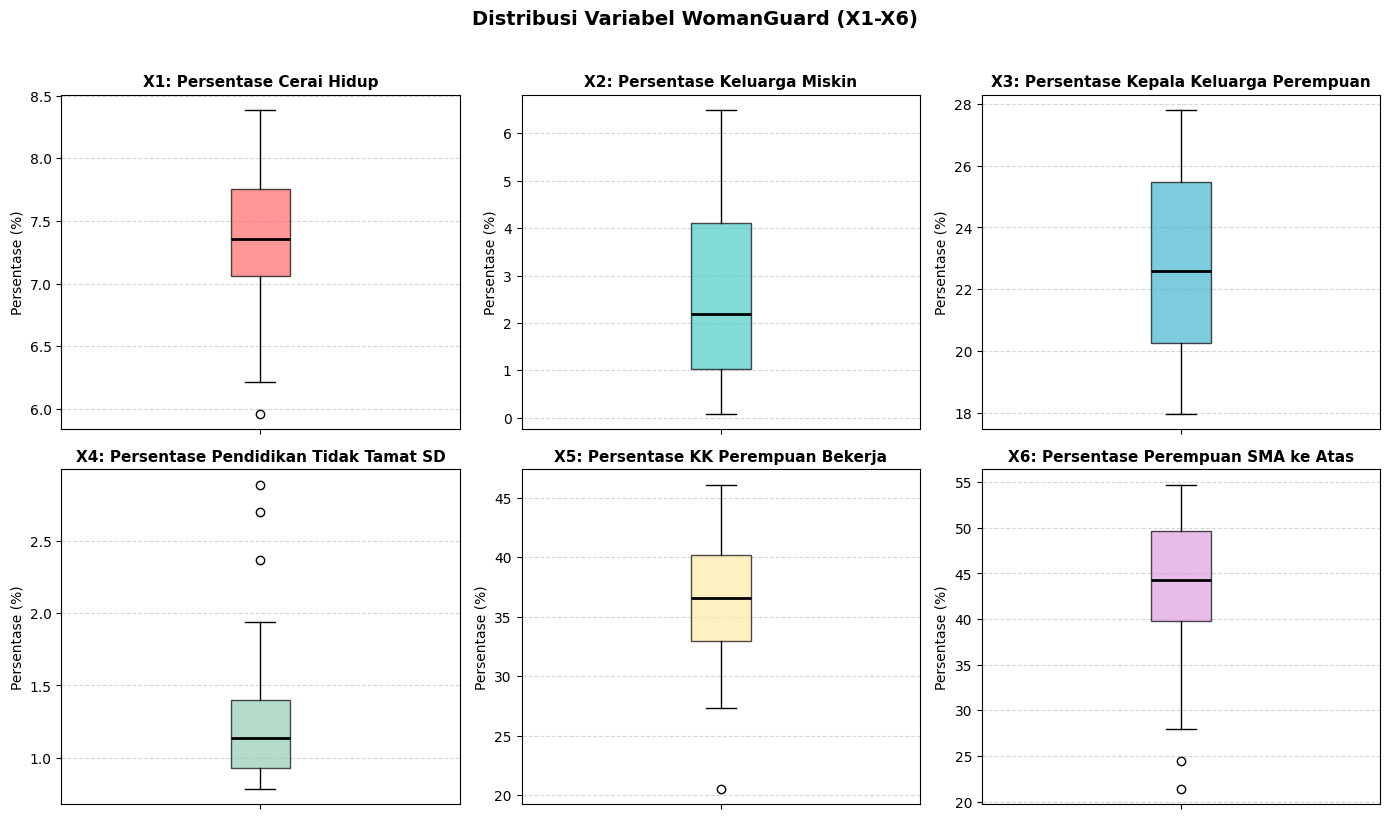

In [ ]:
# Visualisasi boxplot yang lebih rapih
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

# Nama variabel dan judul
var_names = {
    'x1': 'X1: Persentase Cerai Hidup',
    'x2': 'X2: Persentase Keluarga Miskin',
    'x3': 'X3: Persentase Kepala Keluarga Perempuan',
    'x4': 'X4: Persentase Pendidikan Tidak Tamat SD',
    'x5': 'X5: Persentase KK Perempuan Bekerja',
    'x6': 'X6: Persentase Perempuan SMA ke Atas'
}

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']

for i, col in enumerate(['x1', 'x2', 'x3', 'x4', 'x5', 'x6']):
    bp = axes[i].boxplot(df[col], patch_artist=True)
    
    # Styling boxplot
    bp['boxes'][0].set_facecolor(colors[i])
    bp['boxes'][0].set_alpha(0.7)
    bp['medians'][0].set_color('black')
    bp['medians'][0].set_linewidth(2)
    
    axes[i].set_title(var_names[col], fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Persentase (%)', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    axes[i].set_xticklabels([''])

plt.suptitle('Distribusi Variabel WomanGuard (X1-X6)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("D:/KULIAH/Project/womanguard-index-surabaya/output/Boxplot_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

---

### 5.2 Penanganan Outlier — IQR Capping

Outlier dapat mendistorsi hasil PCA dan clustering. Metode yang digunakan adalah **IQR Capping (Winsorization)**: nilai yang berada di luar batas bawah dan atas diganti (di-*clip*) dengan nilai batas tersebut, bukan dihapus.

**Formula batas:**

$$\text{Lower Bound} = Q1 - 1.5 \times IQR$$
$$\text{Upper Bound} = Q3 + 1.5 \times IQR$$

**Keunggulan metode ini:**
- Mempertahankan jumlah observasi (tidak ada data yang hilang)
- Mengurangi dampak nilai ekstrem tanpa menghapus informasi kecamatan

Hasil disimpan dalam `df_clean` agar `df` asli tetap tersimpan untuk referensi.


In [223]:
#Fungsi untuk mengganti outlier dengan Q1 atau Q3
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Ganti outlier
    capped = series.clip(lower=lower_bound, upper=upper_bound)
    return capped

# Terapkan ke semua kolom numerik di df
df_clean = df.copy()

for col in df_clean.select_dtypes(include='number').columns:
    if col != 'Kecamatan':  # Abaikan kolom non-numerik
        df_clean[col] = cap_outliers(df_clean[col])

---
## 6. Standardisasi & Principal Component Analysis (PCA)

### 🎯 Tujuan PCA dalam WomanGuard

PCA digunakan untuk merangkum **4 variabel indikator feminisasi kemiskinan** (X1–X4) menjadi komponen-komponen yang lebih sedikit, namun tetap mempertahankan sebagian besar informasi/varians data.

### 📋 Langkah-langkah

1. **Pemilihan variabel:** Hanya X1–X4 yang dimasukkan ke PCA, karena X5 dan X6 merupakan variabel pemberdayaan yang akan dianalisis terpisah melalui regresi
2. **Standardisasi:** Data di-*scale* menggunakan `StandardScaler` sehingga setiap variabel memiliki mean=0 dan standar deviasi=1. Langkah ini **wajib** sebelum PCA agar variabel dengan satuan/skala berbeda tidak mendominasi
3. **PCA:** Dijalankan tanpa pembatasan jumlah komponen agar dapat melihat seluruh *explained variance ratio*




In [ ]:
# Pilih variabel X1 sampai X4
X = df_clean[['x1', 'x2', 'x3', 'x4']]

# Standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Tampilkan hasil
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)
print(f"\nTotal Explained Variance: {pca.explained_variance_ratio_.sum():.4f}")

# Buat dataframe hasil PCA
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4'])
pca_df['Kecamatan'] = df['Kecamatan']
pca_df.to_csv("D:/KULIAH/Project/womanguard-index-surabaya/output/pca_df.csv", index=False)

pca_df

Explained Variance Ratio:
[0.4694244  0.3758495  0.11479237 0.03993372]

Total Explained Variance: 1.0000


,PC1,PC2,PC3,PC4,Kecamatan
0,0.528320,-0.232409,0.980183,0.245336,karang pilang
1,0.225045,0.495835,0.624863,-0.438165,wonocolo
2,-1.398542,-1.308963,-0.174683,-0.541053,rungkut
3,2.457503,-0.977290,0.185544,0.047559,wonokromo
4,2.699259,0.554632,0.524850,-0.029426,tegalsari
5,1.840749,-0.994256,-0.536842,0.074864,sawahan
6,1.330198,0.294337,-1.339156,-0.127754,genteng
7,1.002670,-1.226613,-0.854173,-0.484592,gubeng
8,0.206383,-1.083119,0.375719,0.106866,sukolilo
9,1.040493,-0.717901,-0.534565,0.474558,tambaksari


### 📊 Interpretasi Output

- **Explained Variance Ratio:** Proporsi varians yang dijelaskan oleh setiap PC
- **PC1** menangkap pola variasi terbesar antar kecamatan
- **PC2** menangkap pola kedua terbesar yang ortogonal dengan PC1

---
## 7. Perhitungan Woman Guard Index (WGI)

### 📐 Formula WGI

WGI dihitung sebagai **kombinasi berbobot dari PC1 dan PC2**, di mana bobot proporsional terhadap *explained variance* masing-masing komponen:

$$w_1 = \frac{\text{Variance}_{PC1}}{\text{Variance}_{PC1} + \text{Variance}_{PC2}} = \frac{0.4694244}{0.4694244 + 0.3758495} \approx 0.555$$

$$w_2 = \frac{\text{Variance}_{PC2}}{\text{Variance}_{PC1} + \text{Variance}_{PC2}} = \frac{0.3758495}{0.4694244 + 0.3758495} \approx 0.4446$$

$$\text{WGI} = w_1 \times PC1 + w_2 \times PC2$$

### 🔴🟢 Interpretasi Nilai WGI

| Nilai WGI | Interpretasi |
|-----------|-------------|
| **Positif (merah)** | Kecamatan dengan kerentanan **di atas rata-rata** — perlu prioritas intervensi |
| **Negatif (hijau)** | Kecamatan dengan kerentanan **di bawah rata-rata** — kondisi relatif lebih baik |

### 📊 Visualisasi yang Dihasilkan

1. **Bar chart horizontal** — menampilkan WGI per kecamatan, diurutkan dari tertinggi ke terendah
2. **Scatter plot PC1 vs PC2** — menampilkan posisi setiap kecamatan dalam ruang komponen utama, diwarnai berdasarkan nilai WGI (merah = rentan, hijau = aman)


Woman Guard Index (PC1 + PC2):
           Kecamatan       PC1       PC2  Woman_Guard_Index
11    pabean cantian  1.868861  1.899479           1.882475
4          tegalsari  2.699259  0.554632           1.745654
10         simokerto  0.827784  2.708815           1.664181
14        krembangan  2.028459  1.070004           1.602284
15          semampir -0.633591  3.330860           1.129195
3          wonokromo  2.457503 -0.977290           0.930229
6            genteng  1.330198  0.294337           0.869605
5            sawahan  1.840749 -0.994256           0.580169
1           wonocolo  0.225045  0.495835           0.345451
9         tambaksari  1.040493 -0.717901           0.258626
20       dukuh pakis  0.791391 -0.409358           0.257480
12           bubutan  0.233310  0.270060           0.249651
0      karang pilang  0.528320 -0.232409           0.190063
7             gubeng  1.002670 -1.226613           0.011423
13            tandes  0.410571 -0.540292          -0.012228
16       

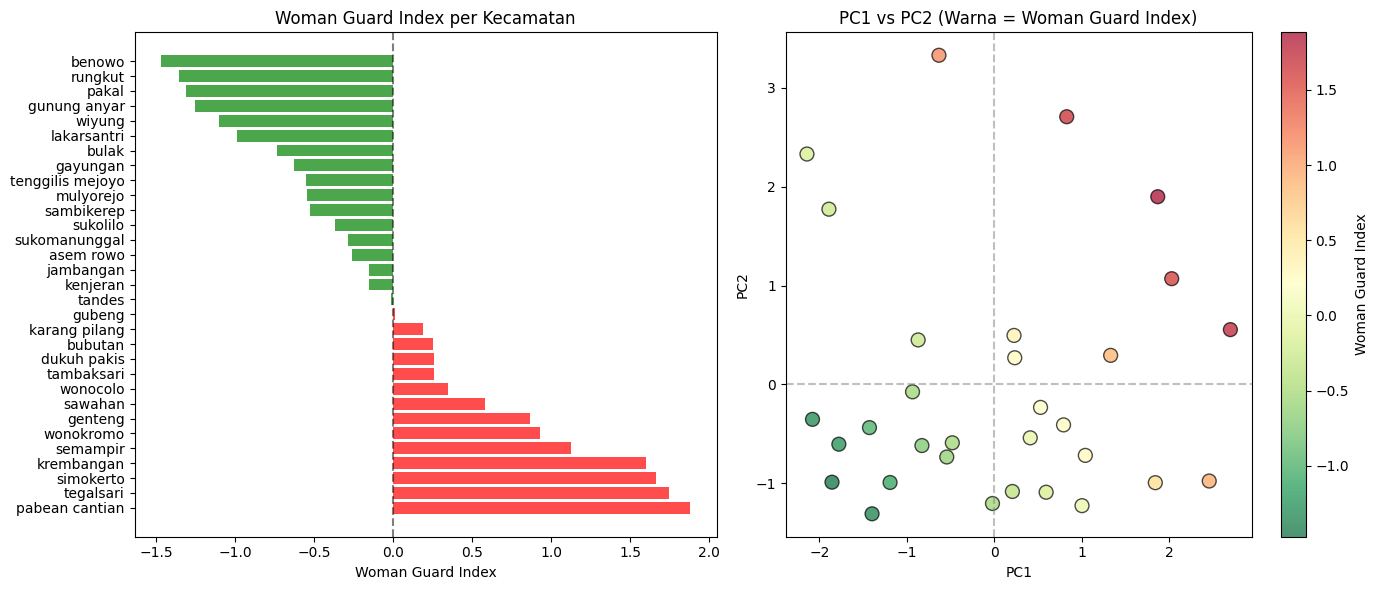


Statistik Woman Guard Index:
Max: 1.8825 (pabean cantian)
Min: -1.4709 (benowo)
Mean: 0.0000
Std: 0.9516


In [ ]:
# Hitung Woman Guard Index = PC1 + PC2 (komponen dengan variance tertinggi)
w1 = pca.explained_variance_ratio_[0] / (pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1])
w2 = pca.explained_variance_ratio_[1] / (pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1])

pca_df = pd.read_csv("D:/KULIAH/Project/womanguard-index-surabaya/output/pca_df.csv")
pca_df['Woman_Guard_Index'] = w1 * pca_df['PC1'] + w2 * pca_df['PC2']

# Tampilkan hasil
print("Woman Guard Index (PC1 + PC2):")
print(pca_df[['Kecamatan', 'PC1', 'PC2', 'Woman_Guard_Index']].sort_values('Woman_Guard_Index', ascending=False))


# Visualisasi
plt.figure(figsize=(14, 6))

# Plot 1: Bar chart Woman Guard Index
plt.subplot(1, 2, 1)
sorted_df = pca_df.sort_values('Woman_Guard_Index', ascending=False)
colors = ['red' if x > 0 else 'green' for x in sorted_df['Woman_Guard_Index']]
plt.barh(sorted_df['Kecamatan'], sorted_df['Woman_Guard_Index'], color=colors, alpha=0.7)
plt.xlabel('Woman Guard Index')
plt.title('Woman Guard Index per Kecamatan')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)

# Plot 2: Scatter PC1 vs PC2 dengan warna berdasarkan WGI
plt.subplot(1, 2, 2)
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Woman_Guard_Index'], 
                      cmap='RdYlGn_r', s=100, alpha=0.7, edgecolors='black')
plt.colorbar(scatter, label='Woman Guard Index')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PC1 vs PC2 (Warna = Woman Guard Index)')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("D:/KULIAH/Project/womanguard-index-surabaya/output/Woman_Guard_Index.png", dpi=300)
plt.show()

# Statistik
print(f"\nStatistik Woman Guard Index:")
print(f"Max: {pca_df['Woman_Guard_Index'].max():.4f} ({pca_df.loc[pca_df['Woman_Guard_Index'].idxmax(), 'Kecamatan']})")
print(f"Min: {pca_df['Woman_Guard_Index'].min():.4f} ({pca_df.loc[pca_df['Woman_Guard_Index'].idxmin(), 'Kecamatan']})")
print(f"Mean: {pca_df['Woman_Guard_Index'].mean():.4f}")
print(f"Std: {pca_df['Woman_Guard_Index'].std():.4f}")

---
## 8. K-Means Clustering

### 🎯 Tujuan Clustering

Clustering digunakan untuk mengelompokkan kecamatan-kecamatan ke dalam **4 kategori kerentanan** berdasarkan posisi mereka dalam ruang PCA (PC1 dan PC2). Empat cluster dipilih untuk menangkap variasi tingkat kerentanan perempuan secara lebih granular, yang kemudian diklasifikasikan menjadi sangat rentan, rentan tinggi, rentan sedang, dan rentan rendah. Pembagian ini diharapkan dapat mendukung perumusan kebijakan yang lebih tepat sasaran berdasarkan tingkat prioritas intervensi.

### ⚙️ Konfigurasi

- **Algoritma:** K-Means dengan `n_clusters=4`
- **Input:** PC1 dan PC2 dari hasil PCA
- **Inisialisasi:** `n_init=10` untuk menghindari konvergensi ke local minimum
- **Random state:** 42 untuk reproducibility

### 📊 Elbow Method

Elbow Method digunakan untuk menentukan jumlah cluster optimal pada K-Means dengan melihat perubahan nilai *inertia* terhadap jumlah cluster (`k`).

Inertia akan menurun seiring bertambahnya jumlah cluster, namun penurunannya akan melambat pada titik tertentu (titik “siku” atau elbow). Titik ini dipilih sebagai jumlah cluster optimal.

Berdasarkan grafik Elbow Method pada data **Woman Guard Index**, titik siku terlihat pada:

> **k = 4**

Sehingga dipilih 4 cluster yang kemudian diinterpretasikan sebagai:
- Sangat Rentan  
- Rentan Tinggi  
- Rentan Sedang  
- Rentan Rendah  


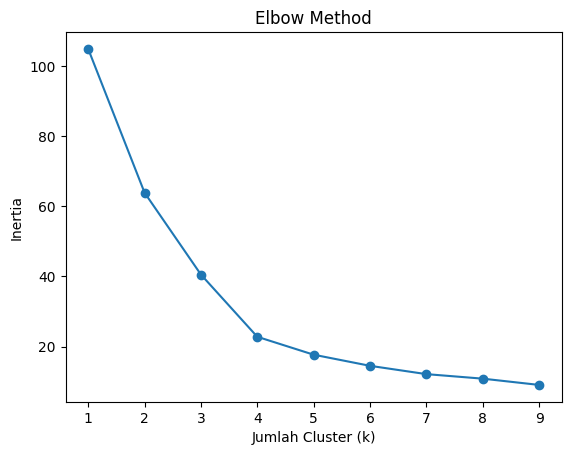

In [11]:
inertia = []

K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_df[['PC1', 'PC2']])
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.savefig("D:/KULIAH/Project/womanguard-index-surabaya/output/Elbow_Method.png", dpi=300)
plt.show()

### 📊 Visualisasi

Scatter plot menampilkan posisi setiap kecamatan dalam ruang PC1-PC2, diwarnai berdasarkan cluster, dilengkapi label nama kecamatan dan marker centroid (tanda X berwarna kuning).

K-Means Clustering Results:
           Kecamatan       PC1       PC2  Cluster  Cluster_Label  \
11    pabean cantian  1.868861  1.899479        0  Sangat Rentan   
4          tegalsari  2.699259  0.554632        0  Sangat Rentan   
10         simokerto  0.827784  2.708815        0  Sangat Rentan   
14        krembangan  2.028459  1.070004        0  Sangat Rentan   
15          semampir -0.633591  3.330860        3  Rentan Tinggi   
3          wonokromo  2.457503 -0.977290        2  Rentan Sedang   
6            genteng  1.330198  0.294337        2  Rentan Sedang   
5            sawahan  1.840749 -0.994256        2  Rentan Sedang   
1           wonocolo  0.225045  0.495835        2  Rentan Sedang   
9         tambaksari  1.040493 -0.717901        2  Rentan Sedang   
20       dukuh pakis  0.791391 -0.409358        2  Rentan Sedang   
12           bubutan  0.233310  0.270060        2  Rentan Sedang   
0      karang pilang  0.528320 -0.232409        2  Rentan Sedang   
7             gubeng

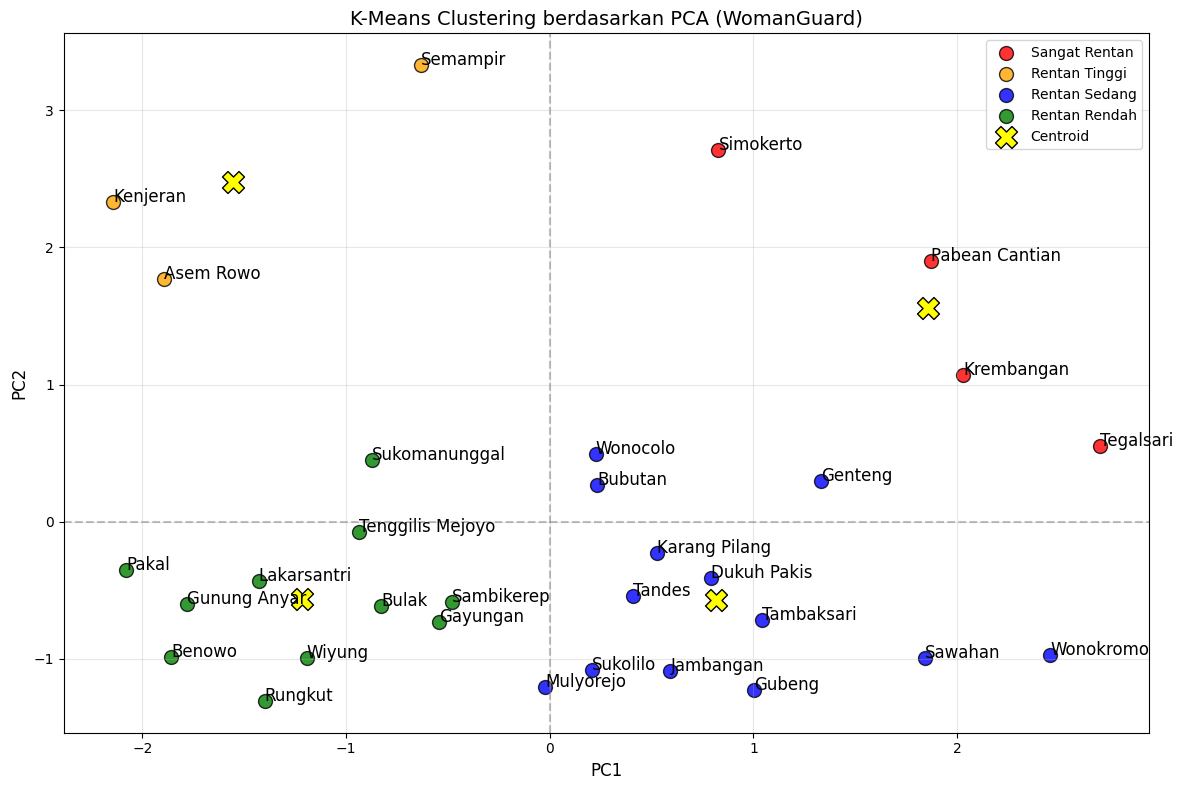


Rata-rata Woman Guard Index per Cluster:
Cluster_Label
Sangat Rentan    1.723648
Rentan Tinggi    0.237889
Rentan Sedang    0.200765
Rentan Rendah   -0.928928
Name: Woman_Guard_Index, dtype: float64


In [ ]:
#Clustering

# Ambil PC1 dan PC2
X_cluster = pca_df[['PC1', 'PC2']]

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
pca_df['Cluster'] = kmeans.fit_predict(X_cluster)

# LABEL BERDASARKAN WGI
cluster_mean = (
    pca_df.groupby('Cluster')['Woman_Guard_Index']
    .mean()
    .sort_values(ascending=False)
)

cluster_mapping = {
    cluster_mean.index[0]: "Sangat Rentan",
    cluster_mean.index[1]: "Rentan Tinggi",
    cluster_mean.index[2]: "Rentan Sedang",
    cluster_mean.index[3]: "Rentan Rendah"
}

pca_df['Cluster_Label'] = pca_df['Cluster'].map(cluster_mapping)

# OUTPUT
print("K-Means Clustering Results:")
print(
    pca_df[['Kecamatan', 'PC1', 'PC2', 'Cluster', 'Cluster_Label', 'Woman_Guard_Index']]
    .sort_values('Woman_Guard_Index', ascending=False)
)

# VISUALISASI
plt.figure(figsize=(12, 8))

# Urutan label sesuai makna
order_labels = ["Sangat Rentan", "Rentan Tinggi", "Rentan Sedang", "Rentan Rendah"]

# Warna konsisten (merah → hijau)
color_map = {
    "Sangat Rentan": "red",
    "Rentan Tinggi": "orange",
    "Rentan Sedang": "blue",
    "Rentan Rendah": "green"
}

# Plot berdasarkan label (INI KUNCI FIX LEGEND)
for label in order_labels:
    cluster_id = [k for k, v in cluster_mapping.items() if v == label][0]
    cluster_data = pca_df[pca_df['Cluster'] == cluster_id]
    
    plt.scatter(
        cluster_data['PC1'], 
        cluster_data['PC2'], 
        c=color_map[label], 
        s=100, 
        alpha=0.8, 
        label=label, 
        edgecolors='black'
    )

# Label kecamatan
for _, row in pca_df.iterrows():
    plt.annotate(
        row['Kecamatan'].title(),
        (row['PC1'], row['PC2']), 
        fontsize=12, 
        alpha=1
    )

# Centroid
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    c='yellow', 
    s=250, 
    marker='X', 
    edgecolors='black', 
    label='Centroid'
)

# Styling
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title('K-Means Clustering berdasarkan PCA (WomanGuard)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()

# Save
plt.savefig("D:/KULIAH/Project/womanguard-index-surabaya/output/Clustering_Results.png", dpi=300)
plt.show()

# RATA-RATA WGI
print("\nRata-rata Woman Guard Index per Cluster:")
print(
    pca_df.groupby('Cluster_Label')['Woman_Guard_Index']
    .mean()
    .sort_values(ascending=False)
)

---
## 9. Visualisasi Woman Guard Index pada Peta Kota Surabaya

Nilai WGI yang **semakin tinggi** mencerminkan kondisi feminisasi kemiskinan yang **semakin parah**, artinya perempuan di wilayah tersebut lebih rentan terhadap kemiskinan, kerentanan ekonomi, dan keterbatasan akses pendidikan. Nilai WGI yang **semakin rendah (negatif)** menunjukkan kondisi yang **relatif lebih baik**.

Peta choropleth berikut menggambarkan sebaran WGI per kecamatan di Kota Surabaya. Semakin **merah** warna suatu kecamatan, semakin **tinggi** nilai WGI-nya. Sebaliknya, warna **hijau tua** menunjukkan nilai WGI yang rendah.

Semua kecamatan berhasil di-match!


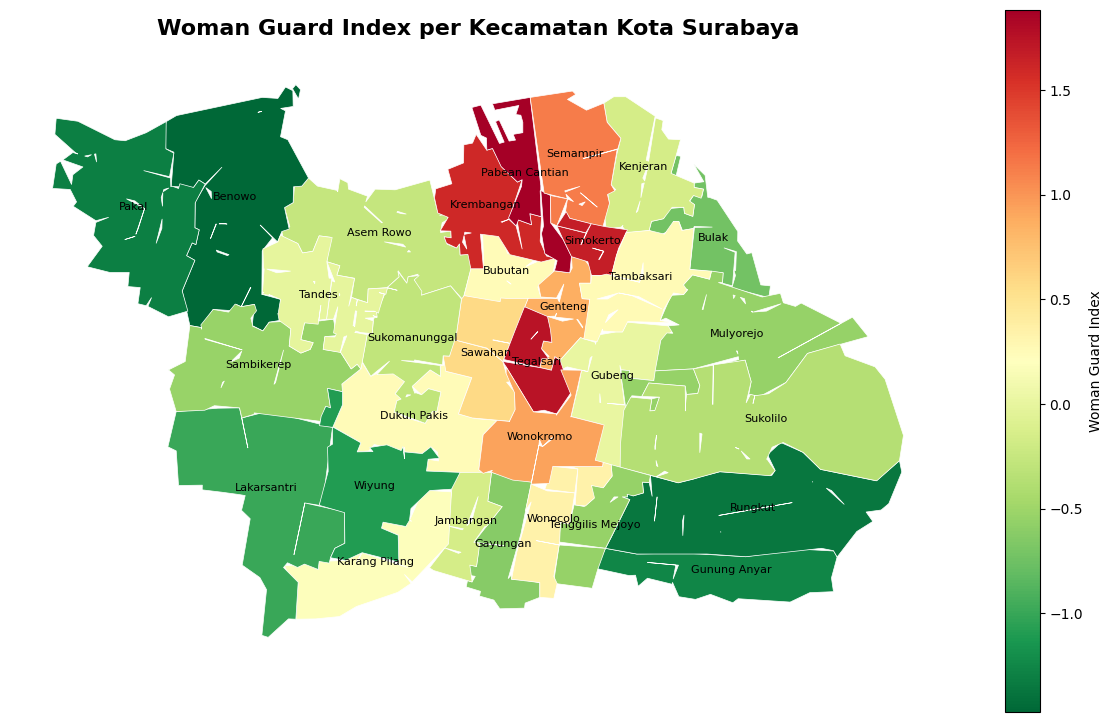

In [ ]:

#Load GeoDataFrame kecamatan Surabaya
with open('Data\gadm41_IDN_4.json', 'r') as f:
    data = json.load(f)

surabaya_features = [
    f for f in data['features']
    if 'Surabaya' in str(f['properties'].get('NAME_2', ''))
]

gdf = gpd.GeoDataFrame.from_features(surabaya_features, crs='EPSG:4326')
kec_gdf = gdf.dissolve(by='NAME_3').reset_index()

# Mapping nama Kecamatan GADM ke format pca_df (lowercase dengan spasi)
gadm_to_pca = {
    'Asemrowo'       : 'asem rowo',
    'Benowo'         : 'benowo',
    'Bubutan'        : 'bubutan',
    'Bulak'          : 'bulak',
    'DukuhPakis'     : 'dukuh pakis',    
    'Gayungan'       : 'gayungan',
    'Genteng'        : 'genteng',
    'Gubeng'         : 'gubeng',
    'GunungAnyar'    : 'gunung anyar',     
    'Jambangan'      : 'jambangan',
    'KarangPilang'   : 'karang pilang',    
    'Kenjeran'       : 'kenjeran',
    'Krembangan'     : 'krembangan',
    'Lakarsantri'    : 'lakarsantri',
    'Mulyorejo'      : 'mulyorejo',
    'PabeanCantian'  : 'pabean cantian',  
    'Pakal'          : 'pakal',
    'Rungkut'        : 'rungkut',
    'Sambikerep'     : 'sambikerep',
    'Sawahan'        : 'sawahan',
    'Semampir'       : 'semampir',
    'Simokerto'      : 'simokerto',
    'SukoManunggal'  : 'sukomanunggal',    
    'Sukolilo'       : 'sukolilo',
    'Tambaksari'     : 'tambaksari',
    'Tandes'         : 'tandes',
    'Tegalsari'      : 'tegalsari',
    'TenggilisMejoyo': 'tenggilis mejoyo', 
    'Wiyung'         : 'wiyung',
    'Wonocolo'       : 'wonocolo',
    'Wonokromo'      : 'wonokromo',
}

kec_gdf['kec_key'] = kec_gdf['NAME_3'].map(gadm_to_pca)

# 3. Merge dengan pca_df
merged = kec_gdf.merge(
    pca_df[['Kecamatan', 'Woman_Guard_Index']],
    left_on='kec_key',
    right_on='Kecamatan',
    how='left'
)

# Debug: cek yang tidak match
no_match = merged[merged['Woman_Guard_Index'].isna()]['NAME_3'].tolist()
if no_match:
    print("Tidak ter-match, cek nama di pca_df:", no_match)
else:
    print("Semua kecamatan berhasil di-match!")

# Visualisasi
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

merged.plot(
    column='Woman_Guard_Index',
    ax=ax,
    cmap='RdYlGn_r',
    legend=True,
    legend_kwds={
        'label': 'Woman Guard Index',
        'orientation': 'vertical',
        'shrink': 0.6
    },
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
    edgecolor='white',
    linewidth=0.5
)

for _, row in merged.iterrows():
    if row.geometry and not row.geometry.is_empty:
        centroid = row.geometry.centroid
        ax.annotate(
            row['kec_key'].title(),
            xy=(centroid.x, centroid.y),
            fontsize=8,
            ha='center',
            color='black'
        )

ax.set_title('Woman Guard Index per Kecamatan Kota Surabaya',
             fontsize=16, fontweight='bold', pad=16)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('D:\KULIAH\Project\womanguard-index-surabaya\output\MAP_woman_guard_index_surabaya.png', dpi=150, bbox_inches='tight')
plt.show()

### Temuan Utama

**Kecamatan dengan kondisi terburuk (WGI tertinggi)** terkonsentrasi di kawasan **Surabaya Utara dan Pusat**:

| Kecamatan | WGI |
|---|---|
| Pabean Cantian | 1,882 |
| Tegalsari | 1,746 |
| Simokerto | 1,664 |
| Krembangan | 1,602 |
| Semampir | 1,129 |
| Wonokromo | 0,930 |
| Genteng | 0,870 |

**Kecamatan dengan kondisi terbaik (WGI terendah)** terkonsentrasi di kawasan **Surabaya Barat dan Timur**:

| Kecamatan | WGI |
|---|---|
| Benowo | −1,471 |
| Rungkut | −1,359 |
| Pakal | −1,312 |
| Gunung Anyar | −1,256 |
| Wiyung | −1,103 |
| Lakarsantri | −0,987 |
| Bulak | −0,735 |

### Pola Spasial

Secara keseluruhan, terdapat **pola gradien spasial yang jelas** dari pinggiran menuju pusat kota. Kawasan **Surabaya Utara** khususnya Pabean Cantian (1,882), Simokerto (1,664), dan Krembangan (1,602) mencatat nilai WGI tertinggi, mengindikasikan tingginya konsentrasi feminisasi kemiskinan di wilayah tersebut. Hal ini sejalan dengan karakteristik kawasan padat penduduk dengan banyak kepala keluarga perempuan berstatus cerai hidup, tingkat kemiskinan yang relatif tinggi, serta rendahnya tingkat pendidikan kepala keluarga.

Sementara itu, kecamatan di **pinggiran barat** (Benowo −1,471; Pakal −1,312; Lakarsantri −0,987; Wiyung −1,103) dan **timur** (Rungkut −1,359; Gunung Anyar −1,256) mencatat nilai WGI terendah, menunjukkan bahwa kondisi feminisasi kemiskinan di wilayah ini relatif lebih terkendali. Kawasan-kawasan ini umumnya memiliki kepadatan penduduk lebih rendah dengan struktur keluarga yang lebih stabil secara ekonomi.

Beberapa kecamatan di **Surabaya Tengah** seperti Gubeng (0,011), Tandes (−0,012), dan Asemrowo (−0,262) berada di zona netral mendekati nol, mencerminkan kondisi feminisasi kemiskinan yang moderat, tidak tergolong kritis, namun tetap memerlukan perhatian.

---
## 9. Regresi Linear — Pengaruh Pemberdayaan Ekonomi terhadap WGI

### 🎯 Tujuan

Setelah WGI dihitung dari variabel feminisasi kemiskinan (X1–X4), tahap ini menguji apakah variabel **pemberdayaan ekonomi perempuan** (X5 dan X6) memiliki pengaruh signifikan terhadap WGI.

### 📐 Model Regresi

$$\text{WGI} = \beta_0 + \beta_1 \cdot X5 + \beta_2 \cdot X6 + \varepsilon$$

- **Y (Dependen):** `Woman_Guard_Index` dari hasil PCA
- **X5 (Independen 1):** Persentase kepala keluarga perempuan yang bekerja
- **X6 (Independen 2):** Persentase perempuan berpendidikan SMA ke atas

### 💡 Hipotesis yang Diuji

| Variabel | Hipotesis |
|----------|-----------|
| X5 | Semakin tinggi partisipasi kerja perempuan → WGI menurun (kerentanan berkurang) |
| X6 | Semakin tinggi pendidikan perempuan → WGI menurun (kerentanan berkurang) |

Koefisien negatif pada X5 dan X6 akan mengkonfirmasi bahwa pemberdayaan ekonomi berperan dalam menurunkan kerentanan.


In [229]:
Y = pca_df["Woman_Guard_Index"]

df['x5'] = pd.to_numeric(df['x5'], errors='coerce')

X_pred = df[['x5','x6']]

---

### 9.1 Fitting Model Linear Regression

Model `LinearRegression` dari scikit-learn di-*fit* menggunakan `X_pred` (X5 dan X6) sebagai prediktor dan `Y` (WGI) sebagai target.

**Output yang ditampilkan:**
- **Intercept (β₀):** Nilai WGI ketika X5 dan X6 sama dengan 0
- **Coefficient X5 (β₁):** Perubahan WGI untuk setiap kenaikan 1% partisipasi kerja perempuan
- **Coefficient X6 (β₂):** Perubahan WGI untuk setiap kenaikan 1% perempuan berpendidikan SMA ke atas
- **R-squared (R²):** Proporsi varians WGI yang dapat dijelaskan oleh X5 dan X6


In [235]:
reg = LinearRegression()
X_reg = df[['x5', 'x6']]
reg.fit(X_reg, Y)

print(f"Intercept: {reg.intercept_:.6f}")
print(f"Coefficient X5: {reg.coef_[0]:.6f}")
print(f"Coefficient X6: {reg.coef_[1]:.6f}")
print(f"R-squared: {reg.score(X_reg, Y):.6f}\n")

print(f"X6 {abs(reg.coef_[1]/reg.coef_[0]):.2f} kali lebih berpengaruh dari X5")

Intercept: 1.939663
Coefficient X5: -0.006312
Coefficient X6: -0.039830
R-squared: 0.161238

X6 6.31 kali lebih berpengaruh dari X5


---

### 9.2 Visualisasi Linear Regression

Tiga panel visualisasi ditampilkan untuk memahami hubungan antara variabel prediktor dan WGI:

1. **Panel Kiri — X5 vs WGI:** Scatter plot dengan garis regresi (X6 tidak diikutkan)
2. **Panel Tengah — X6 vs WGI:** Scatter plot dengan garis regresi (X5 tidak diikutkan)
3. **Panel Kanan — Actual vs Predicted:** Menilai seberapa baik model memprediksi WGI; semakin dekat titik ke garis diagonal merah putus-putus, semakin akurat model

> 💡 Garis diagonal merah putus-putus pada panel ketiga merepresentasikan *perfect fit* (prediksi = aktual). Deviasi dari garis ini adalah residual model.


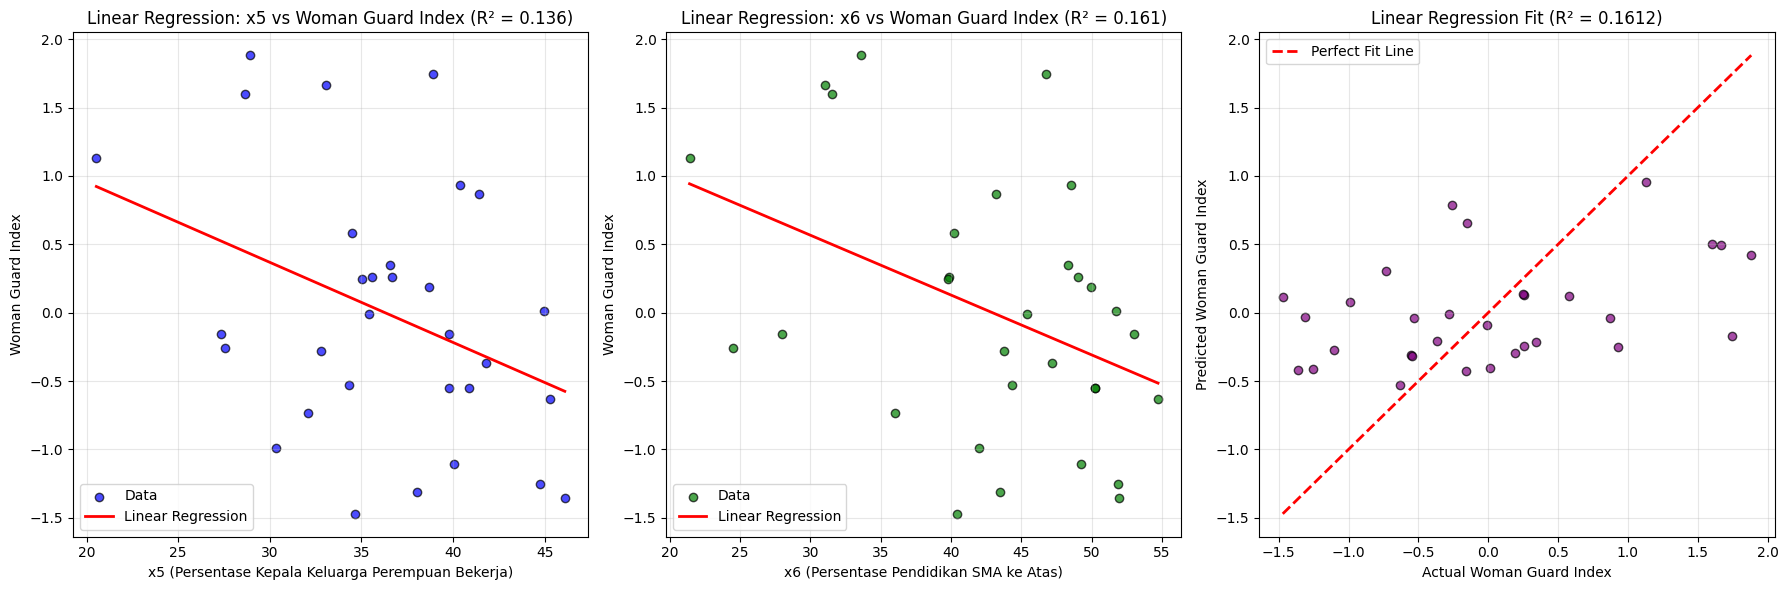

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# PLOT 1: LINEAR REGRESSION x5
reg_x5 = LinearRegression()
reg_x5.fit(df[['x5']].values, Y)

axes[0].scatter(df['x5'], Y, color='blue', alpha=0.7, edgecolors='black', label='Data')

x5_line = np.linspace(df['x5'].min(), df['x5'].max(), 100).reshape(-1, 1)
y_simple_x5 = reg_x5.predict(x5_line)

r2_x5 = reg_x5.score(df[['x5']].values, Y)

axes[0].plot(x5_line, y_simple_x5, color='red', linewidth=2,
             label='Linear Regression')

axes[0].set_xlabel('x5 (Persentase Kepala Keluarga Perempuan Bekerja)')
axes[0].set_ylabel('Woman Guard Index')
axes[0].set_title(f'Linear Regression: x5 vs Woman Guard Index (R² = {r2_x5:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# PLOT 2: LINEAR REGRESSION x6
reg_x6 = LinearRegression()
reg_x6.fit(df[['x6']].values, Y)

axes[1].scatter(df['x6'], Y, color='green', alpha=0.7, edgecolors='black', label='Data')

x6_line = np.linspace(df['x6'].min(), df['x6'].max(), 100).reshape(-1, 1)
y_simple_x6 = reg_x6.predict(x6_line)

r2_x6 = reg_x6.score(df[['x6']].values, Y)

axes[1].plot(x6_line, y_simple_x6, color='red', linewidth=2,
             label='Linear Regression')

axes[1].set_xlabel('x6 (Persentase Pendidikan SMA ke Atas)')
axes[1].set_ylabel('Woman Guard Index')
axes[1].set_title(f'Linear Regression: x6 vs Woman Guard Index (R² = {r2_x6:.3f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)


# PLOT 3: ACTUAL vs PREDICTED (MULTIPLE REGRESSION)
Y_pred = reg.predict(X_reg)

axes[2].scatter(Y, Y_pred, color='purple', alpha=0.7, edgecolors='black')

min_val = min(Y.min(), Y_pred.min())
max_val = max(Y.max(), Y_pred.max())

axes[2].plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=2, label='Perfect Fit Line')

axes[2].set_xlabel('Actual Woman Guard Index')
axes[2].set_ylabel('Predicted Woman Guard Index')
axes[2].set_title(f'Linear Regression Fit (R² = {reg.score(X_reg, Y):.4f})')
axes[2].legend()
axes[2].grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig("D:/KULIAH/Project/womanguard-index-surabaya/output/Linear_Regression_Visualization.png", dpi=300)
plt.show()

---
## 10. Analisis Perbandingan & Korelasi

### 🔍 Perbandingan WGI dengan Variabel Asli (X1–X6)

Cell ini menggabungkan DataFrame asli `df` dengan hasil WGI dan label cluster, kemudian:
1. Menampilkan tabel lengkap semua kecamatan beserta nilai X1–X6, WGI, dan cluster label (diurutkan dari WGI tertinggi)
2. Membuat **heatmap korelasi** antara semua variabel (X1–X6) dan WGI

### 🌡️ Interpretasi Heatmap Korelasi

- Nilai mendekati **+1.0**: Korelasi positif kuat — variabel tersebut bergerak searah dengan WGI (meningkatkan kerentanan)
- Nilai mendekati **-1.0**: Korelasi negatif kuat — variabel tersebut bergerak berlawanan dengan WGI (menurunkan kerentanan)
- Nilai mendekati **0**: Tidak ada hubungan linear

> 🎯 **Yang diharapkan:** X1, X2, X3, X4 berkorelasi **positif** dengan WGI (indikator kerentanan), sedangkan X5, X6 berkorelasi **negatif** (indikator pemberdayaan).


=== Perbandingan Woman Guard Index dengan Variabel Asli (x1-x6) ===
       Kecamatan       x1       x2        x3       x4        x5        x6  Woman_Guard_Index Cluster_Label
  pabean cantian 7.386779 6.038996 27.266533 1.670868 28.935532 33.574056           1.882475 Sangat Rentan
       tegalsari 8.018005 6.330063 27.173877 1.224306 38.897754 46.748575           1.745654 Sangat Rentan
       simokerto 6.764978 4.983302 27.103074 1.939676 33.079797 31.061817           1.664181 Sangat Rentan
      krembangan 7.765830 6.490240 25.305098 1.441657 28.639836 31.562002           1.602284 Sangat Rentan
        semampir 5.959580 4.490507 24.648223 2.697586 20.533024 21.397413           1.129195 Rentan Tinggi
       wonokromo 8.385648 4.534781 26.145541 0.827430 40.363694 48.572925           0.930229 Rentan Sedang
         genteng 7.736475 2.186382 27.804933 1.376033 41.442716 43.181818           0.869605 Rentan Sedang
         sawahan 8.252222 2.896873 26.202542 0.929637 34.480816 40.221222   

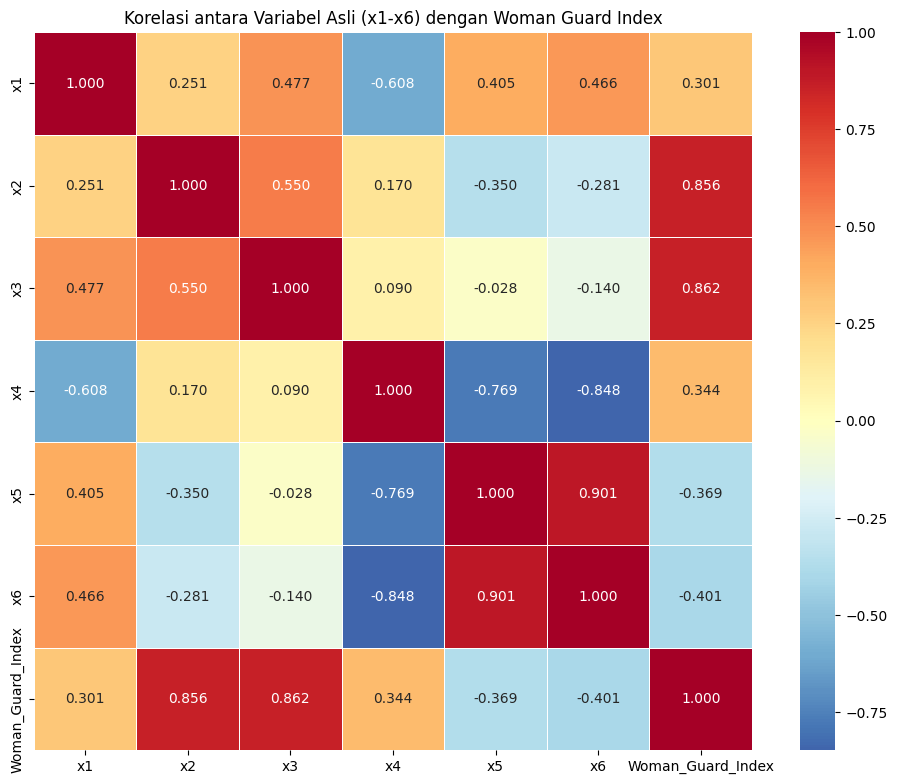


=== Korelasi setiap variabel dengan Woman Guard Index ===
x1: 0.3013
x2: 0.8557
x3: 0.8617
x4: 0.3438
x5: -0.3690
x6: -0.4012


In [ ]:
# Gabungkan data asli dengan Woman Guard Index
comparison_df = df.copy()
comparison_df['Woman_Guard_Index'] = pca_df['Woman_Guard_Index'].values
comparison_df['Cluster_Label'] = pca_df['Cluster_Label'].values

# Urutkan berdasarkan Woman Guard Index
comparison_df = comparison_df.sort_values('Woman_Guard_Index', ascending=False)

# Tampilkan tabel perbandingan
print("=== Perbandingan Woman Guard Index dengan Variabel Asli (x1-x6) ===")
print(comparison_df.to_string(index=False))

# Visualisasi heatmap korelasi
plt.figure(figsize=(10, 8))
corr_cols = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'Woman_Guard_Index']
correlation_matrix = comparison_df[corr_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0, 
            fmt='.3f', square=True, linewidths=0.5)
plt.title('Korelasi antara Variabel Asli (x1-x6) dengan Woman Guard Index', fontsize=12)
plt.tight_layout()
plt.savefig("D:/KULIAH/Project/womanguard-index-surabaya/output/Correlation_Comparison.png", dpi=300)
plt.show()

# Tampilkan korelasi dengan WGI
print("\n=== Korelasi setiap variabel dengan Woman Guard Index ===")
for col in ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']:
    corr = comparison_df[col].corr(comparison_df['Woman_Guard_Index'])
    print(f"{col}: {corr:.4f}")

---
## 11. Uji Multikolinearitas — Variance Inflation Factor (VIF)

### 🎯 Tujuan

Sebelum mempercayai hasil regresi linear sepenuhnya, perlu dilakukan uji **multikolinearitas** untuk memastikan bahwa variabel prediktor (X5 dan X6) tidak saling berkorelasi terlalu tinggi satu sama lain.

### 📐 Variance Inflation Factor (VIF)

VIF mengukur seberapa besar varians koefisien regresi mengalami inflasi akibat multikolinearitas:

$$VIF_j = \frac{1}{1 - R^2_j}$$

di mana $R^2_j$ adalah koefisien determinasi dari regresi variabel $j$ terhadap semua variabel lainnya.




In [233]:
# Gunakan X_pred (x5 dan x6)
X = X_pred.copy()

# Tambahkan konstanta
X['const'] = 1

# Hitung VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

  Variable        VIF
0       x5   5.320935
1       x6   5.320935
2    const  40.447220


### 📊 Interpretasi Nilai VIF

| Nilai VIF | Interpretasi |
|-----------|-------------|
| < 5 | ✅ Multikolinearitas rendah — aman |
| 5 – 10 | ⚠️ Multikolinearitas sedang — perlu diperhatikan |
| > 10 | ❌ Multikolinearitas tinggi — masalah serius |

Konstanta (`const`) ditambahkan ke dalam X sebelum menghitung VIF, sesuai dengan konvensi `statsmodels`.

---

## 📌 Ringkasan Akhir

### 🏁 Kesimpulan Metodologi WomanGuard

| Tahap | Metode | Output |
|-------|--------|--------|
| Pengumpulan Indikator | Kalkulasi persentase dari data administrasi | DataFrame X1–X6 per kecamatan |
| Penanganan Outlier | IQR Capping | `df_clean` |
| Reduksi Dimensi | PCA pada X1–X4 | PC1, PC2 |
| Indeks Komposit | Weighted PCA Score | `Woman_Guard_Index` |
| Pemetaan Prioritas | K-Means Clustering (k=3) | Label: Rentan Tinggi/Sedang/Rendah |
| Analisis Pemberdayaan | Regresi Linear (X5, X6 → WGI) | Koefisien & R² |
| Validasi Model | Korelasi & VIF | Interpretasi hubungan antar variabel |

### 🗺️ Output Peta Kebijakan

Hasil akhir WomanGuard memberikan **peta prioritas pembangunan perempuan** di 31 kecamatan Kota Surabaya, yang dapat digunakan oleh:
- **Dinas Pemberdayaan Perempuan dan Perlindungan Anak (DP3A)** untuk alokasi program intervensi
- **Bappeko Surabaya** untuk perencanaan pembangunan berbasis data gender
- **Akademisi dan peneliti** sebagai referensi indeks kerentanan berbasis feminisasi kemiskinan

---
*WomanGuard — Memastikan setiap perempuan di Surabaya mendapat perlindungan dan kesempatan yang layak.*
